# Predicting Student Success with XGBoost and Stacking


We will predict whether a student passes using:

1. **XGBoost** — many small trees that correct earlier mistakes
2. **Random Forest** — many independent trees whose votes are averaged
3. **K-Nearest Neighbours (KNN)** — predicts from similar students
4. **Stacking** — combines all three using **Logistic Regression** as the meta learner

By the end, you should be able to explain not only *how* to code stacking, but also *why* five-fold out-of-fold predictions are needed.


## 0. Setup

Run the next cell once if `xgboost` is not already installed. After installation, restart the kernel if your notebook asks you to.

In [1]:
# Uncomment and run only if XGBoost is missing:
# %pip install xgboost pandas scikit-learn matplotlib

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

RANDOM_STATE = 42

## 1. Load and understand the data

Each row represents one student. The target is `passed`:

- `0` = did not pass
- `1` = passed

The dataset is stored as `student.csv` in the `week-8-ml` folder.

In [3]:
possible_paths = [Path("student.csv"), Path("week-8-ml/student.csv")]
data_path = next((path for path in possible_paths if path.is_file()), None)

if data_path is None:
    raise FileNotFoundError(
        "Could not find week-8-ml/student.csv. Run from the notebook folder or repository root."
    )

df = pd.read_csv(data_path)
print(f"Loaded {data_path} — {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())

Loaded student.csv — 1200 rows × 9 columns


,hours_studied_weekly,attendance_pct,previous_exam_score,practice_tests_completed,sleep_hours,tutoring_sessions,assignment_completion_pct,class_participation,passed
0,4.5,79,58,0,7.3,2,63,4,0
1,3.3,73,60,4,8.0,2,70,4,0
2,3.3,79,53,1,6.2,1,57,5,0
3,3.3,65,43,4,7.6,2,65,3,0
4,14.5,88,66,3,5.5,0,71,4,1


In [4]:
print("Missing values:", int(df.isna().sum().sum()))
print("Duplicate rows:", int(df.duplicated().sum()))

class_summary = (
    df["passed"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Did not pass", 1: "Passed"})
    .to_frame("students")
)
class_summary["percentage"] = (
    100 * class_summary["students"] / len(df)
).round(1)
display(class_summary)

Missing values: 0
Duplicate rows: 0


,students,percentage
passed,,
Did not pass,624,52.0
Passed,576,48.0


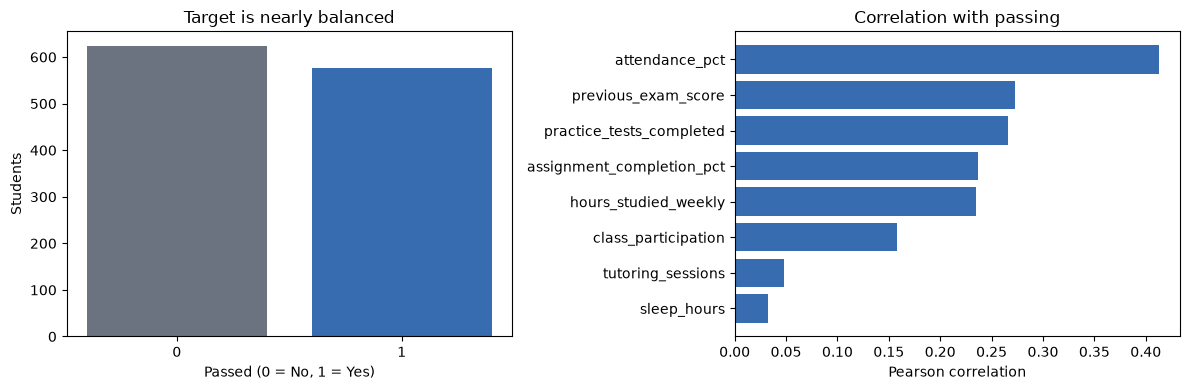

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

pass_counts = df["passed"].value_counts().reindex([0, 1], fill_value=0)
axes[0].bar(pass_counts.index, pass_counts.values, color=["#6b7280", "#386cb0"])
axes[0].set_xticks([0, 1])
axes[0].set_title("Target is nearly balanced")
axes[0].set_xlabel("Passed (0 = No, 1 = Yes)")
axes[0].set_ylabel("Students")

corr = df.corr(numeric_only=True)["passed"].drop("passed").sort_values()
axes[1].barh(corr.index, corr.values, color="#386cb0")
axes[1].set_title("Correlation with passing")
axes[1].set_xlabel("Pearson correlation")

plt.tight_layout()
plt.show()

## 2. Prepare one fair train/test split

We train on 80% of the rows and reserve 20% for a final test. `stratify=y` keeps almost the same pass/fail proportion in both sets.

In [6]:
X = df.drop(columns="passed")
y = df["passed"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Training pass rate:", round(y_train.mean(), 3))
print("Test pass rate:", round(y_test.mean(), 3))

Training rows: 960
Test rows: 240
Training pass rate: 0.48
Test pass rate: 0.479


## 3. Meet the three base learners

### XGBoost

XGBoost builds trees **sequentially**. Each new tree focuses on mistakes made by the current ensemble. A smaller `learning_rate` makes each new tree contribute less; `n_estimators` controls how many trees are added.

### Random Forest

Random Forest builds many trees **independently** from random samples of rows and features, then averages their predictions. Randomness helps the trees make different mistakes.

### KNN

KNN looks for the `k` most similar training examples. Because distance is sensitive to units, KNN is placed after `StandardScaler`; otherwise a feature ranging from 0–100 could dominate one ranging from 1–5.

In [7]:
xgb_model = XGBClassifier(
    n_estimators=120,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.90,
    colsample_bytree=0.90,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rf_model = RandomForestClassifier(
    n_estimators=250,
    max_depth=7,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=15),
)

In [8]:
def evaluate_model(name, model, X_eval, y_eval):
    predicted_class = model.predict(X_eval)
    predicted_probability = model.predict_proba(X_eval)[:, 1]

    return {
        "model": name,
        "accuracy": accuracy_score(y_eval, predicted_class),
        "precision": precision_score(y_eval, predicted_class, zero_division=0),
        "recall": recall_score(y_eval, predicted_class, zero_division=0),
        "f1": f1_score(y_eval, predicted_class, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, predicted_probability),
    }


base_models = {
    "XGBoost": xgb_model,
    "Random Forest": rf_model,
    "KNN": knn_model,
}

base_results = []
fitted_base_models = {}

for name, model in base_models.items():
    fitted_model = clone(model).fit(X_train, y_train)
    fitted_base_models[name] = fitted_model
    base_results.append(evaluate_model(name, fitted_model, X_test, y_test))

base_results_df = pd.DataFrame(base_results).set_index("model")
display(base_results_df.style.format("{:.3f}").highlight_max(axis=0, color="#d8f3dc"))

,accuracy,precision,recall,f1,roc_auc
model,,,,,
XGBoost,0.746,0.729,0.748,0.738,0.839
Random Forest,0.750,0.731,0.757,0.744,0.848
KNN,0.750,0.752,0.713,0.732,0.841


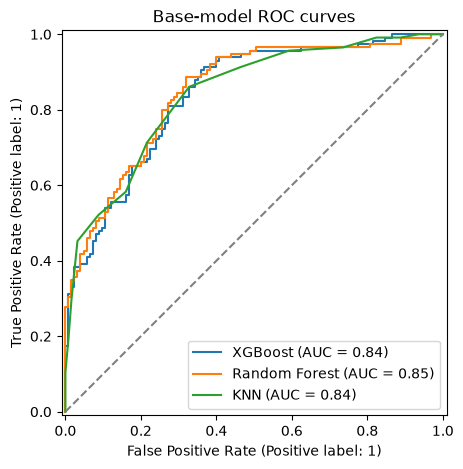

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in fitted_base_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)

ax.plot([0, 1], [0, 1], "--", color="grey", label="Random guessing")
ax.set_title("Base-model ROC curves")
plt.show()

**Metric reminder:**

- **Accuracy:** fraction of all predictions that are correct
- **Precision:** among predicted passes, how many truly passed?
- **Recall:** among students who passed, how many did we identify?
- **F1:** balances precision and recall
- **ROC-AUC:** how well the model ranks passing students above non-passing students across thresholds

## 4. Stacking: let another model combine the models

The base learners each output a probability:

| Student | XGBoost | Random Forest | KNN | True result |
|---|---:|---:|---:|---:|
| A | 0.90 | 0.82 | 0.73 | 1 |
| B | 0.42 | 0.35 | 0.61 | 0 |

Logistic Regression learns how to combine those three probabilities:

$$P(\text{pass}) = \sigma(b_0 + b_1p_{XGB} + b_2p_{RF} + b_3p_{KNN})$$

where $\sigma$ converts the score into a probability between 0 and 1.

### Why the “5-fold” step matters

If a base model predicts rows that it already trained on, its predictions may look unrealistically good. The meta learner would learn from leaked, overconfident predictions.

Instead, split the training set into five folds:

| Round | Train base models on | Predict |
|---:|---|---|
| 1 | Folds 2–5 | Fold 1 |
| 2 | Folds 1, 3–5 | Fold 2 |
| 3 | Folds 1–2, 4–5 | Fold 3 |
| 4 | Folds 1–3, 5 | Fold 4 |
| 5 | Folds 1–4 | Fold 5 |

After five rounds, **every training student has three predictions from models that did not train on that student**. These are called **out-of-fold predictions**. Logistic Regression learns from this new three-column dataset.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

stacking_model = StackingClassifier(
    estimators=[
        ("xgb", clone(xgb_model)),
        ("rf", clone(rf_model)),
        ("knn", clone(knn_model)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    stack_method="predict_proba",
    cv=cv,
    passthrough=False,
    n_jobs=-1,
)

stacking_model.fit(X_train, y_train)
stacking_result = evaluate_model(
    "Stacking Ensemble", stacking_model, X_test, y_test
)
display(pd.DataFrame([stacking_result]).set_index("model").style.format("{:.3f}"))

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Stacking Ensemble,0.762,0.742,0.774,0.757,0.849
